In [45]:
import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsmodels.tsa.seasonal import seasonal_decompose

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from IPython.display import display, Markdown, Image

from fpppy.utils import plot_series

# endregion 
from plotnine import *

# change working directory 
# Check if current directory has any .ipynb files
if any(fname.endswith(".ipynb") for fname in os.listdir()):
    os.chdir("..")

# load local package modules
from gas_pump_prices.preprocess import * 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Chapter 8: Exponential smoothing

## 8.1. Simple exponential smoothing

A simple exponential smoothing model provides a middle ground between a naïve method (where predictions are simple equal to the past observation) and the average method (where predictions are simply the historical average) such that predictions are weighted sum of ast observations, where weights decay exponentially with time. 

$$
\hat{y}_{T+1|T} = \alpha y_T + \alpha (1 - \alpha) y_{T-1} +\alpha (1 - \alpha)^2 y_{T-2} + ... + \alpha (1 - \alpha)^n y_{T-n} 
$$

Importantly, smaller values of $\alpha$ give greater weight to more distant values. 

Values of $\alpha$ can be determined by minimizing sum of squares. 

Exponential smoothing can be presented in two forms: weighted average form and component form. Both are equivalent to each other with the weighted component form providing an intuition (i.e., mainly that forecasts are weighted averages of past observations, with weights decaying exponentially over time) and the components form providing the framework for understanding more advanced analyses (e.g., state-space models).

### Weighted average form 

On new data, a forecast at time $T+1$ is equal to the weighted average of the most recent observation ($y_T$) and the previous forecast ($\hat{y}_{T|T-1}$): 

$$
\hat{y}_{T+1|T} = \alpha y_T + (1-\alpha)\hat{y}_{T|T-1}.
$$

For the fitted values (recall these are the one-step forecasts on the training data), 
$$
\hat{y}_{t+1|t} = \alpha y_t + (1-\alpha)\hat{y}_{t|t-1}.
$$

Because each previous value is iteratively multiplied by $(1-\alpha)$ with each additional forecast, the weighted average form yields 

$$
\hat{y}_{T|T+1} = (\sum^{T-1}_{j=0} \alpha(1-\alpha)^j y_{T-j}) + (1-\alpha)^T \ell_0, 
$$

where $\ell_0$ is the first fitted value (which must be estimated). 

### Component form 

For now, just know that the component form expression for a simple exponential smoothing model is provided by 

$$
\begin{aligned}
\text{Forecast equation}: \hat{y}_{t+h|t} &= \ell_t \\ 
\text{Smoothing equation}: \ell_t &= \alpha y_t + (1-\alpha)\ell_{t-1}
\end{aligned}.
$$

Note that h=1 gives the fitted values and setting t=T gives the true forecasts (beyond the training data). 

### Optimization 

Any exponential smoothing methods requires estimating the initial values for the weight ($\alpha$) and the first fitted value ($\ell_0$). As in regression, these values can be estimated by minimizing the sum of squared errors on the training data. As a recap, for any $t$ time point in the training data, the residual is given by $e_t = y_t - \hat{y}_{t|t-1}$. Values for $\alpha$ and $\ell_0$ can be estimated by minimizing 

$$
SSE = \sum^T_{t=1} (y_t - \hat{y}_{t|t-1})^2
$$

Optimal parameters:
alpha: 0.8401
Initial level: 39.53


/opt/anaconda3/lib/python3.12/site-packages/utilsforecast/processing.py:384: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
/opt/anaconda3/lib/python3.12/site-packages/utilsforecast/processing.py:440: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.


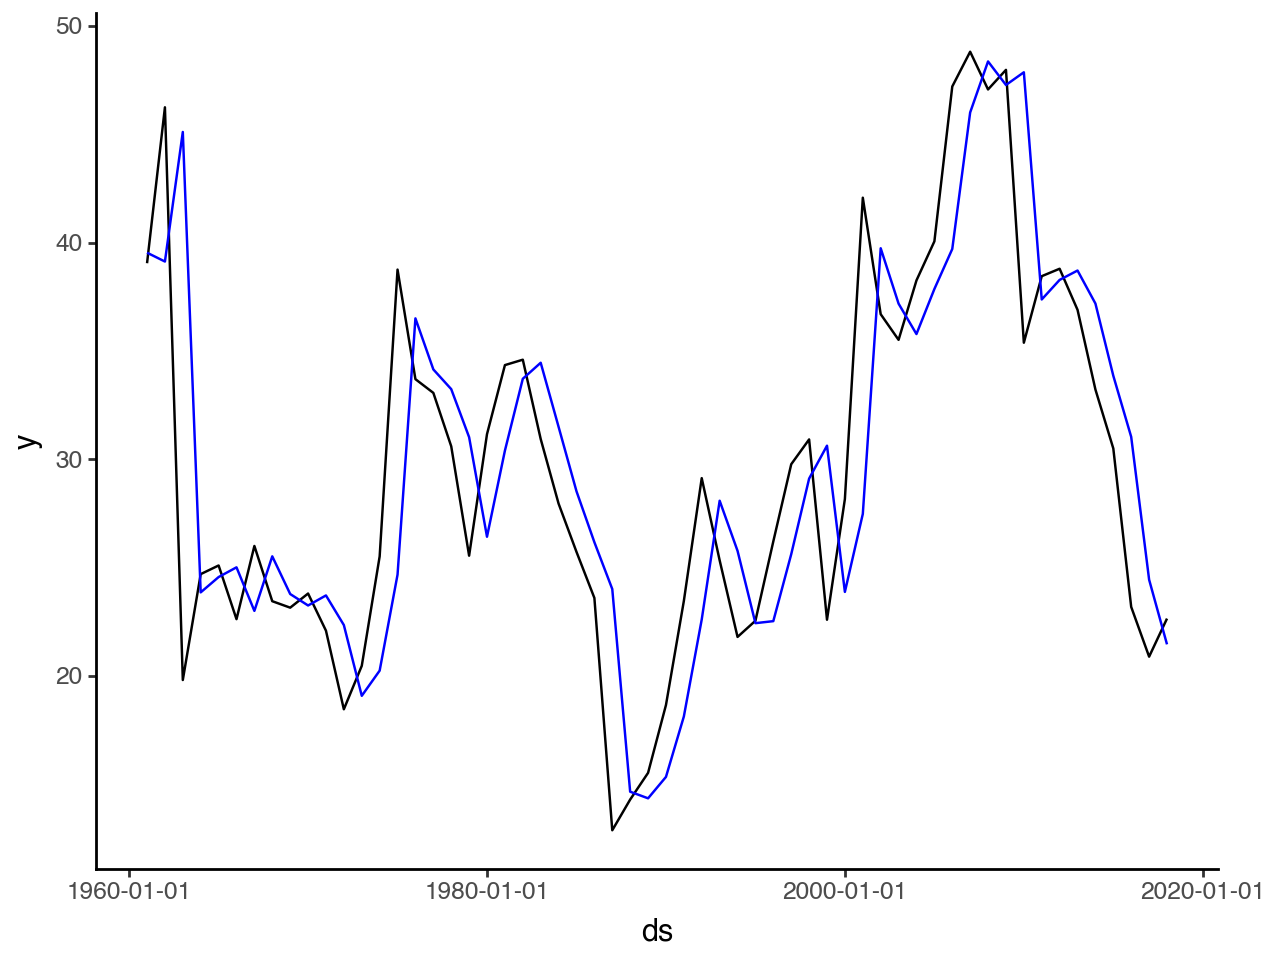

In [ ]:
# Example: Modelling Algerian exports using simple exponential smoothing method 
df_alg = pd.read_csv('data/raw/algeria_exports.csv', parse_dates=['ds'])

# simple exponential smoothing is an instanceof AutoETS()
# NOTE: model='ANN' uses an Additive error, No tren, No seasosonality
# alias simply gives a name to the model predictions 
sf = StatsForecast(models=[AutoETS(season_length=1, model="ANN", alias="SES")], freq="Y")

# generate forecasts 
df_forecast = sf.forecast(df=df_alg, h=5, level=[80, 95], fitted=True)
df_fitted = sf.forecast_fitted_values()

# store model parameters 
# NOTE: forecast(0 method does not store parameters )
ses = AutoETS(season_length=1, model="ANN", alias="SES")
ses = ses.fit(y=df_alg["y"].values)

params = np.round(ses.model_["fit"][0],4)
print("Optimal parameters:")
print("alpha:", params[0])
print("Initial level:", params[1])

df_comb = pd.concat(objs=[df_fitted, df_forecast])

# (ggplot(data=df_fitted, mapping=aes(x='ds', y='y')) + 
#  geom_line() + 
#  geom_line(mapping=aes(x='ds', y='SES'), color='blue') + 
#  theme_classic())


## 8.2. Methods with trend 

### Holt's linear trend method

Applies exponential smoothing to the estimation of an average level and a trend. Thus, there are two smoothing equations: 

$$
\begin{aligned}
\text{Forecast equation}: \hat{y}_{t+h|t} &= \ell_t + hb_t \\ 
\text{Level equation}: \ell_t &= \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}) \\ 
\text{Trend equation}: b_t &= \beta^\ast (\ell_t - \ell_{t-1}) + (1-\beta^\ast)(b_{t-1} + b_{t-1})
\end{aligned}, 
$$

where $ell_t$ denotes the level estimate at time $t$. $b_t$ is the slope (trend) estimate of the series at time $t$, $\alpha$ is the smoothing parameter on the level, and $\beta^\ast$ is the smoothing parameter on the slope. 

Here is the intuition behind Holt's linear method: 

1. The trend equation is updated by computing a weighted sum of the most recent slope estimate, $\beta^\ast (\ell_t - \ell_{t-1})$, and the previous slope estimate, $(1-\beta^\ast)(b_{t-1} + b_{t-1})$. 
2. The level equation is similarly updated by taking the weighted sum of the most recent value, $\alpha y_t$, and the most recent estimate of the level value, $(1-\alpha)(\ell_{t-1} + b_{t-1})$. Note that the most recent slope is added to the most recent estimate of the level to bring it forward one step.

In the below example with annual population growth in Australia, the high value of $\hat{\alpha}=.9999$ indicates that the level changes rapidly.

### Damped trend methods 

The main limitation with Holt's method is that hte trend estimate is constant, which leads to over/underestimates over longer periods of time. To solve this problem, a dampening variable ($\phi$) can be added that flattens the trend over time. Because the dampening is exppnential, values of $\phi$ seldom go below .8 in practice. 

$$
\begin{aligned}
\text{Forecast equation}: \hat{y}_{t+h|t} &= \ell_t + (\phi + \phi^2 + ... + \phi^h)b_t \\ 
\text{Level equation}: \ell_t &= \alpha y_t + (1-\alpha)(\ell_{t-1} + \phi b_{t-1}) \\ 
\text{Trend equation}: b_t &= \beta^\ast (\ell_t - \ell_{t-1}) + (1-\beta^\ast)(b_{t-1} + \phi b_{t-1})
\end{aligned}, 

$$


Optimal parameters:
alpha: 0.9999
beta: 0.2001
Initial level: 10.0509
Initial trend: 0.2264


/opt/anaconda3/lib/python3.12/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


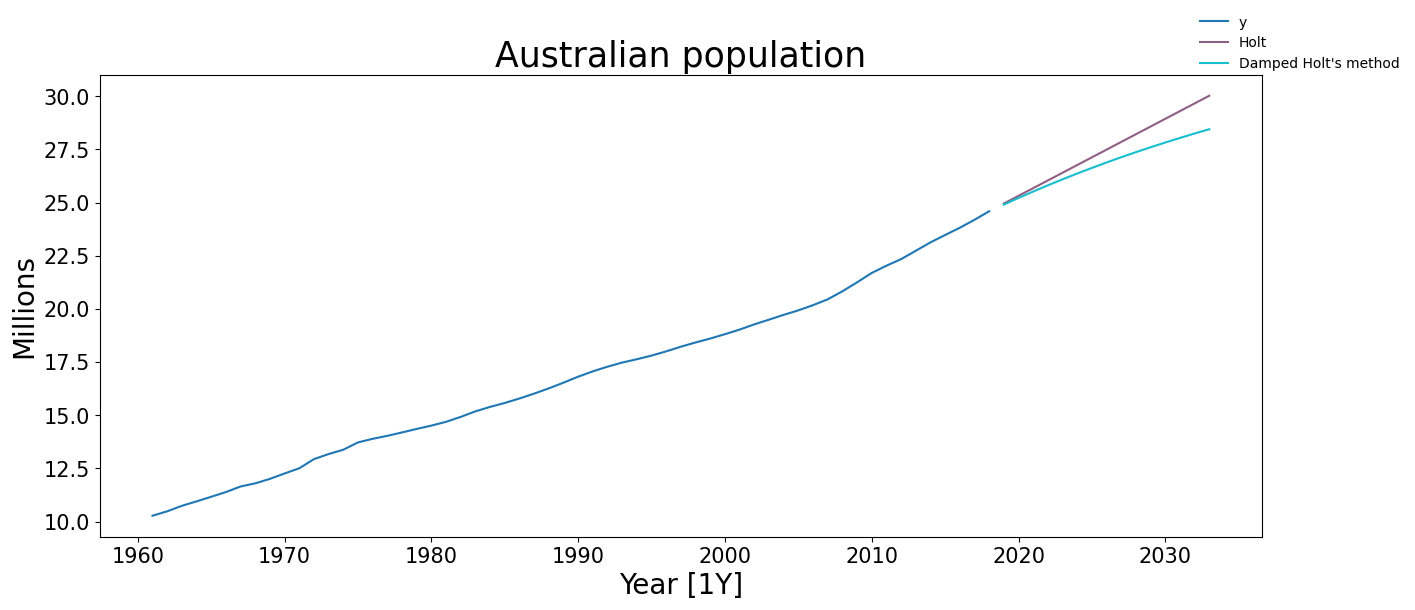

In [ ]:
# Example: Australian (yearly) population using Holt's method (with and withou dampening)
df_aus = pd.read_csv('data/raw/aus_economy.csv', parse_dates=['ds'])

df_aus["y"] = df_aus["y"] / 1e6
# plot_series(df_aus, xlabel="Year [1Y]", ylabel="Millions", title="Australian population")

# apply Holt's method 
sf = StatsForecast(models=[AutoETS(season_length=1, model="AAN", alias="Holt")], freq="YE")

fc = sf.forecast(df=df_aus, h=10)

autoets = AutoETS(season_length=1, model="AAN", alias="Holt")
autoets = autoets.fit(y=df_aus["y"].values)

params = np.round(autoets.model_["fit"][0], 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

sf = StatsForecast(models=[AutoETS(season_length=1, model="AAN", alias="Holt"),
                           AutoETS(season_length=1, model="AAN", damped=True, phi=0.9, 
                                   alias="Damped Holt's method")],freq="YE",)

fc = sf.forecast(df=df_aus, h=15)

plot_series(df_aus, fc, xlabel="Year [1Y]", ylabel="Millions", title="Australian population", rm_legend=False)

## 8.3. Methods with seasonality

As it stands, Holt's method (even with dampening) cannot only forecast direction changes. To do so, a seasonality component needs to be added. Therefore, three components now comprise the forecasting equation: 

$$
\begin{aligned}
\text{Forecast equation}: \hat{y}_{t+h|t} &= \ell_t + hb_t + s_{t+h-m(k+1)} \\ 
\text{Level equation}: \ell_t &= \alpha (y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1} + b_{t-1}) \\ 
\text{Trend equation}: b_t &= \beta^\ast (\ell_t - \ell_{t-1}) + (1-\beta^\ast)b_{t-1} \\ 
\text{Season equation}: s_t &= \gamma (y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m}
\end{aligned}, 
$$

where $m$ indicates the length of the season (e.g., $m=4$ with quarterly data) and $k$ is the nearest integer of $(h-1)/m$. Note that using $t+h-m(k+1)$ ensures the seasonal estimate comes from the correct time last year (i.e., data from the last season). Like the trend and level equations, the season equation is weighted average of the current seasonal index and the seasonal index from the same season last year.

Here is the intuition: 

1. Level equation is a weighted sum of seasonally adjusted observations. Importantly, they trend component influences both seasonally adjusted parts. 
2. Season equation is a weighted sum of current and previous seasonal indices. 

/opt/anaconda3/lib/python3.12/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


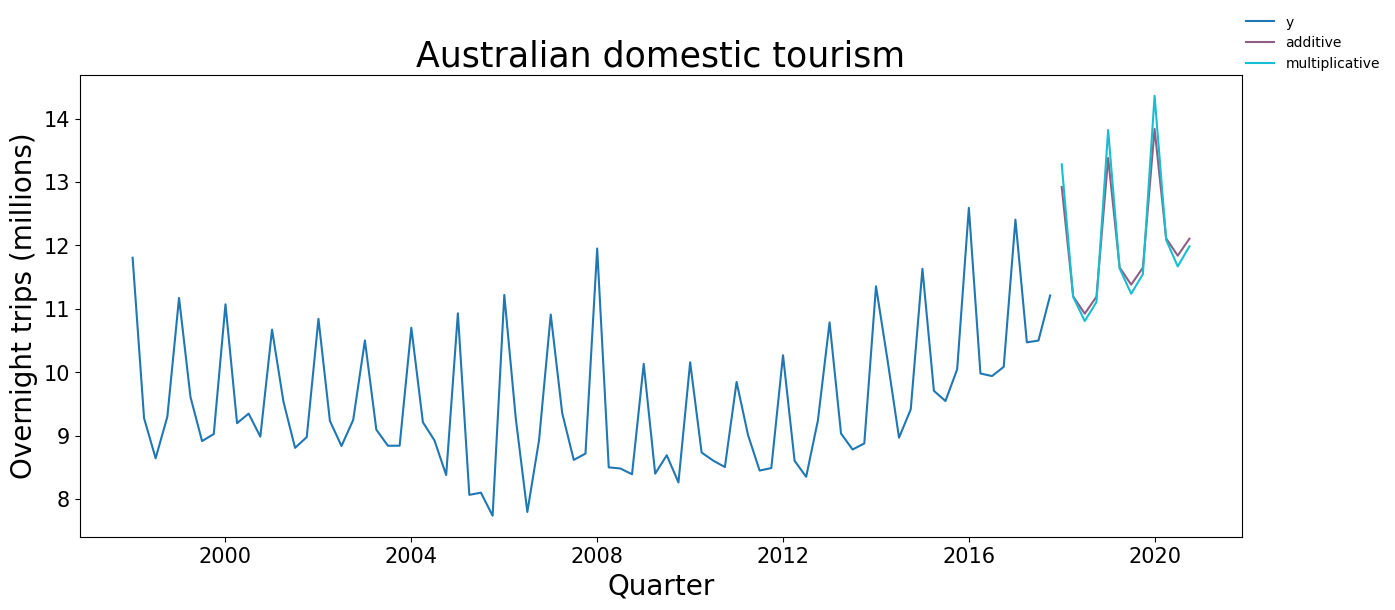

,unique_id,metric,additive,multiplicative
0,Holiday,rmse,0.412279,0.411543


Optimal parameters:
alpha: 0.2325
beta: 0.03
gamma: 0.0001
Initial level: 9.8372
Initial seasonal components: [-0.0238 -0.5386 -0.6916 -0.3051]


In [77]:
# Example: Domestic overnight trips in Australia 
df_tourism = pd.read_csv('data/raw/tourism.csv', parse_dates=['ds'])

df_holiday = (df_tourism.query('Purpose == "Holiday"')
                .groupby(["Purpose", "ds"], as_index=False)["y"].sum())
df_holiday["y"] = df_holiday["y"] / 1e3
df_holiday.rename(columns={"Purpose": "unique_id"}, inplace=True)

sf = StatsForecast(models=[AutoETS(season_length=4, model="AAA", alias="additive"), 
                           AutoETS(season_length=4, model="MAM", alias="multiplicative")],
                           freq="QE") 

fc = sf.forecast(df=df_holiday, h=12, fitted=True)
sf = sf.fit(df_holiday)
plot_series(df_holiday, fc, xlabel="Quarter", ylabel="Overnight trips (millions)", 
            title="Australian domestic tourism", rm_legend=False)

# evaluate model on fitted values 
fitted_vals = sf.forecast_fitted_values()
evaluate(fitted_vals, metrics=[rmse])

# extraction of parameter 
autoets = AutoETS(season_length=4, model="AAA")
autoets = autoets.fit(y=aus_holidays["y"].values)

params = np.round(autoets.model_["fit"][0], 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("gamma:", params[2])
print("Initial level:", params[3])
print("Initial seasonal components:", params[4:len(params)])


### Holt-Winter's  damped method 
Dampening is still needed for Holt-Winter's method because this method can still over/underpredict change over time. 

/opt/anaconda3/lib/python3.12/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


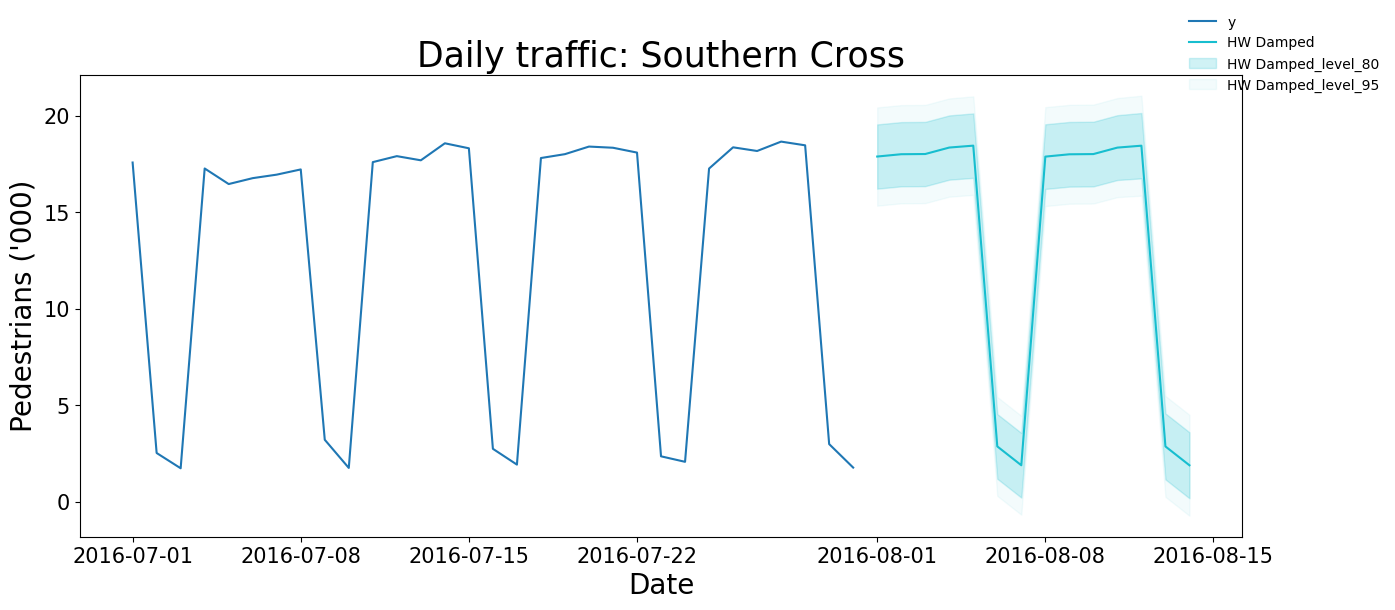

In [62]:
df_pedes = pd.read_csv("data/raw/pedestrian.csv", parse_dates=["ds"])

sth_cross_ped = (df_pedes.query(
    'ds >= "2016-07-01" and ds <= "2016-07-31" and unique_id == "Southern Cross Station"')
    .groupby(["unique_id", "ds"], as_index=False)["y"].sum())
sth_cross_ped["y"] = sth_cross_ped["y"] / 1000

sf = StatsForecast(models=[AutoETS(season_length=7, model="MAM", damped=True, alias="HW Damped")],
                   freq="D",)

fc = sf.forecast(df=sth_cross_ped, h=14, level=[80, 95])
plot_series(sth_cross_ped, fc, level=[80, 95], xlabel="Date", ylabel="Pedestrians ('000)", title="Daily traffic: Southern Cross", rm_legend=False)

## 8.4. A taxonomy of exponential smoothing methods

In [67]:
data = {
    "Short hand": ["(N, N)", "(A, N)", "(Aₑ, N)", "(A, A)", "(A, M)", "(Aₑ, A)"],
    "Method": [
        "Simple exponential smoothing",
        "Holt’s linear method",
        "Additive damped trend method",
        "Additive Holt–Winters’ method",
        "Multiplicative Holt–Winters’ method",
        "Holt–Winters’ damped method"
    ]
}

df = pd.DataFrame(data)
df

,Short hand,Method
0,"(N, N)",Simple exponential smoothing
1,"(A, N)",Holt’s linear method
2,"(Aₑ, N)",Additive damped trend method
3,"(A, A)",Additive Holt–Winters’ method
4,"(A, M)",Multiplicative Holt–Winters’ method
5,"(Aₑ, A)",Holt–Winters’ damped method


## 8.5. Innovations state space models for exponential smoothing

State space models are made up of measurement and state equations. Measurement equations describe the observed data and state equations capture how the unobserved components (i.e., level, trend, season) change over time. These models can generate point forecasts and prediction intervals. State space models have additive and multiplicative decompositions, which provide different prediction intervals (even when using the same smoothing parameter values). 

State space models are labelled using three letters(ETS; Error, Trend, Seasonal) with the following possibilities: 

1. Error: Addition, Multiplicative
2. Trend: None, Additive, Additive with dampening ($A_d$)
3. Season: None,  Additive, Multiplicative 

### ETS (A, N, N): Simple exponential smoothing with additive errors

Using the component form equation of simple exponential smoothing, we can get the state space model equation.

$$
\begin{aligned}
\text{Forecast equation}: \hat{y}_{t+1|t} &= \ell_t \\
\text{Smoothing equation}: \ell_t &= \alpha y_t + (1-\alpha)\ell_{t-1}
\end{aligned}
$$

The smoothing equation above can be rearranged to obtain 

$$
\begin{aligned}
\ell_t &= \ell_{t-1} + \alpha(y-t - \ell_{t-1}) \\ 
&=\ell_{t-1} + \alpha e_t
\end{aligned}, 
$$

where $e_t = y_t - \ell_{t-1} = y_t - y_{t|t-1}$ is the residual at time $t$. Thus, training data error adjusts the level estimate throughout smoothing such that, if $e_t$ is negative, then the previous trend estimate ($\ell_{t-1}$) overestimated the observed value at time $t$ (i.e., $y_t \lt \hat{y}_{t|t-1}$), which means that the previous trend estimate will be adjusted downwards according to its weighting by $\alpha$. 

Given that residuals are central in updating trend estimates, the following state space equations are obtained for a simple exponential smoothing equation for the observed data: 

$$
\begin{aligned}
y_t &= \ell_{t-1} + e_t \\ 
\ell_t &= \ell_{t-1} + \alpha e_t \\ 
e_t &~ NID (0, \sigma^2)
\end{aligned},
$$

where the first line desbribes the observed data (measurement equation) and the second line describes the latent trend component (state equation). 

Note that the use of 'innovations' is apropos because of how residuals (which can be seen as new information) update estimates of latent components. The use of 'state' is apropos because it describes how the latent components change over time. 

As an aside, note that if $\alpha=1$, the model becomes a random walk model because each next observation is simply equal to the previous observation. 

## 8.6. Estimation and model selection 

Instead of minimizing the sum of squared errors, values for initial states can be estimated by maximizing the likelihood function. These two methods yield the same values when using additive error models, but not multiplicative error models.

### Model selection 

Because state space models have well-defined likelihood functions, information criteria can be used to select models (i..e, AIC, AICc, BIC). 

Note that multiplicative ETS models of ETS(A, N, M), ETS(AAM), ETS(A $A_d$ M) because of division by zero or near-zero values. 

In [103]:
# Example: Domestic holiday tourist visitor nights in Australia 
# NOTE: model is selected by minimizing the AICc (by default)
autoets = AutoETS(season_length=4)
autoets = autoets.fit(y=df_holiday["y"].values)
# autoets.model_["method"]

# 'ETS(M,N,M)' is the best model

params = np.round(autoets.model_["fit"][0], 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("gamma:", params[1])
print("Initial level for series:", params[2])
print("Initial seasonal components:", params[3:len(params)])



Optimal parameters:
alpha: 0.3612
gamma: 0.0001
Initial level for series: 9.7878
Initial seasonal components: [0.9432 0.9268 0.9683]


## 8.7. Forecasting with ETS models

ETS model forecasts can be obtained using the `forecast()` method. This method will always return the mean of the forecast distribution. For most models, prediction intervals are provided by 

$$
\hat{t}_{T+h|T} \pm c \sigma_h, 
$$

where c depends on the coverage probability and $\sigma^2_h$ is the forecast variance. Note that the computation for $\sigma^2_h$ is complex and differs across each ETS model. In cases where no known formula exists for computing prediction intervals, `StatsForecast` constructs intervals using simulated future paths. 

/opt/anaconda3/lib/python3.12/site-packages/utilsforecast/processing.py:384: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
/opt/anaconda3/lib/python3.12/site-packages/utilsforecast/processing.py:440: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
/opt/anaconda3/lib/python3.12/site-packages/fpppy/utils.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


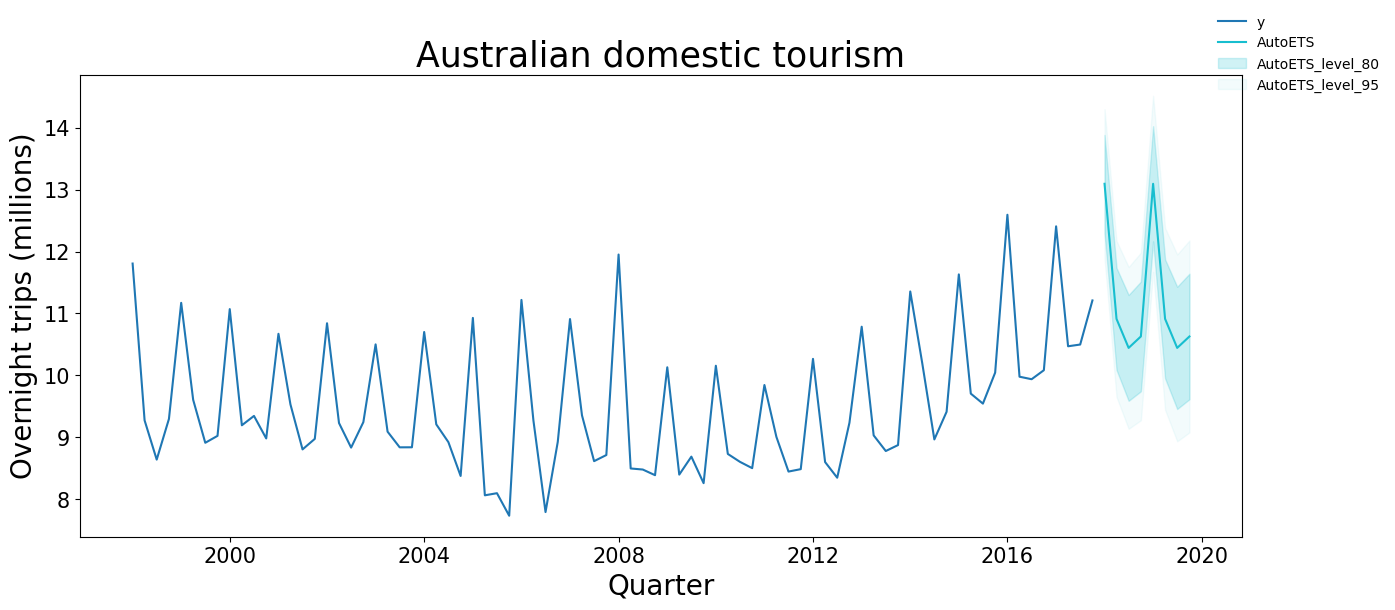

In [78]:
sf = StatsForecast(models=[AutoETS(season_length=4)], freq="Q")

fc = sf.forecast(df=df_holiday, h=8, level=[80, 95])
plot_series(df_holiday, fc, level=[80, 95], xlabel="Quarter", ylabel="Overnight trips (millions)", title="Australian domestic tourism", rm_legend=False)

## 8.8. Exercises

### 1. Number of pigs slaughtered in Victoria 

In [138]:
df_livestock = pd.read_csv('data/raw/aus_livestock.csv', parse_dates=['ds'])
df_pigs = df_livestock.loc[df_livestock['unique_id'].eq('Victoria_Pigs')]

# estimate a simple exponential smoothing model using ETS framework 
# NOTE: does not store model parameters 
sf = StatsForecast(
    models=[AutoETS(season_length=4, model="ANN", alias="additive")],
    freq="ME")

df_forecast = sf.forecast(df=df_pigs, h=4, fitted=True, level=[80, 95])
sf = sf.fit(df_pigs)

# examine model parameters 
ses = AutoETS(season_length=4, model="ANN", alias="additive")
ses = ses.fit(y=df_pigs["y"].values)

params = np.round(ses.model_["fit"][0],4)
print("Optimal parameters:")
print("alpha:", params[0])
print("Initial level:", params[1])


# compute forecast using 1.96 * std_residuals
df_fitted = sf.forecast_fitted_values()
df_fitted['residual'] = df_fitted['y'] - df_fitted['additive']

# compute 95% pred interval margin 
pred_interval = 1.96 * df_fitted['residual'].std()

df_forecast['calc-lo-95'] = df_forecast['additive'] - pred_interval
df_forecast['calc-hi-95'] = df_forecast['additive'] + pred_interval


# use actual equation 
df_forecast

Optimal parameters:
alpha: 0.3218
Initial level: 100558.5995


,unique_id,ds,additive,additive-lo-95,additive-lo-80,additive-hi-80,additive-hi-95,calc-lo-95,calc-hi-95
0,Victoria_Pigs,2018-12-31,95187.073363,76822.248619,83178.959904,107195.186822,113551.898107,76871.529313,113502.617413
1,Victoria_Pigs,2019-01-31,95187.073363,75894.979049,82572.650922,107801.495804,114479.167676,76871.529313,113502.617413
2,Victoria_Pigs,2019-02-28,95187.073363,75010.279314,81994.176858,108379.969868,115363.867412,76871.529313,113502.617413
3,Victoria_Pigs,2019-03-31,95187.073363,74162.774725,81440.023393,108934.123332,116211.372001,76871.529313,113502.617413


In [126]:
fc.head() 

,unique_id,ds,additive,additive-lo-95,additive-lo-80,additive-hi-80,additive-hi-95
0,Victoria_Pigs,2018-12-31,95187.073363,76822.248619,83178.959904,107195.186822,113551.898107
1,Victoria_Pigs,2019-01-31,95187.073363,75894.979049,82572.650922,107801.495804,114479.167676
2,Victoria_Pigs,2019-02-28,95187.073363,75010.279314,81994.176858,108379.969868,115363.867412
3,Victoria_Pigs,2019-03-31,95187.073363,74162.774725,81440.023393,108934.123332,116211.372001


In [125]:
df_pigs.tail()

,unique_id,ds,y
24337,Victoria_Pigs,2018-08-01,102500.0
24338,Victoria_Pigs,2018-09-01,82600.0
24339,Victoria_Pigs,2018-10-01,100700.0
24340,Victoria_Pigs,2018-11-01,98500.0
24341,Victoria_Pigs,2018-12-01,92300.0
